In [7]:
import tensorflow as tf

In [8]:
mnist = tf.keras.datasets.mnist

In [9]:
(x_train, y_train),(x_test , y_test) = mnist.load_data()

In [10]:
x_train.shape

(60000, 28, 28)

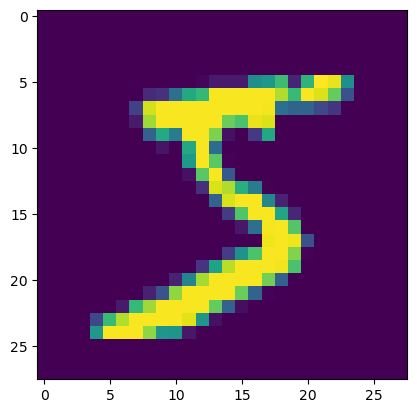

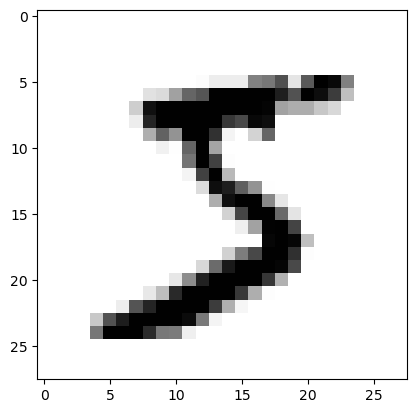

In [11]:
import matplotlib.pyplot as plt
plt.imshow(x_train[0])
plt.show()
plt.imshow(x_train[0] , cmap = plt.cm.binary)

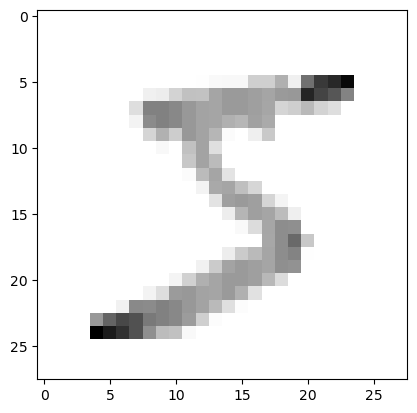

In [12]:
x_train = tf.keras.utils.normalize(x_train , axis = 1)
x_test = tf.keras.utils.normalize(x_test , axis = 1)
plt.imshow(x_train[0] , cmap = plt.cm.binary)

In [13]:
print(x_train[0])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

In [14]:
print(y_train[0])

5


In [15]:
import numpy as np
img_size = 28
x_trainer = np.array(x_train).reshape(-1,img_size,img_size,1)
x_tester = np.array(x_test).reshape(-1,img_size,img_size,1)
print('Training shape' , x_trainer.shape)
print('Testing shape' , x_tester.shape)

Training shape (60000, 28, 28, 1)
Testing shape (10000, 28, 28, 1)


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout , Activation, Flatten , Conv2D, MaxPooling2D

In [17]:
model = Sequential()

model.add(Conv2D(32 , (3,3) , activation = 'relu' , input_shape= x_trainer.shape[1:]))
# model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64 , (3,3) , activation = 'relu'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

# model.add(Conv2D(64 , (3,3) , activation = 'relu'))
# model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(256, activation = 'relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation = 'softmax'))

In [18]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 conv2d_1 (Conv2D)           (None, 24, 24, 64)        18496     
                                                                 
 max_pooling2d (MaxPooling2  (None, 12, 12, 64)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 12, 12, 64)        0         
                                                                 
 flatten (Flatten)           (None, 9216)              0         
                                                                 
 dense (Dense)               (None, 256)               2359552   
                                                        

In [19]:
model.compile(optimizer = 'adam' , loss = 'sparse_categorical_crossentropy' , metrics = ['accuracy'])

In [20]:
model.fit(x_trainer,y_train, epochs = 10 , validation_split = 0.3 , batch_size = 128,verbose=1)

Epoch 1/10
329/329 [==============================] - 41s 121ms/step - loss: 0.2925 - accuracy: 0.9109 - val_loss: 0.0906 - val_accuracy: 0.9721
Epoch 2/10
329/329 [==============================] - 39s 118ms/step - loss: 0.0912 - accuracy: 0.9727 - val_loss: 0.0695 - val_accuracy: 0.9794
Epoch 3/10
329/329 [==============================] - 39s 119ms/step - loss: 0.0648 - accuracy: 0.9802 - val_loss: 0.0508 - val_accuracy: 0.9846
Epoch 4/10
329/329 [==============================] - 40s 122ms/step - loss: 0.0494 - accuracy: 0.9850 - val_loss: 0.0476 - val_accuracy: 0.9859
Epoch 5/10
329/329 [==============================] - 39s 119ms/step - loss: 0.0393 - accuracy: 0.9871 - val_loss: 0.0480 - val_accuracy: 0.9865
Epoch 6/10
329/329 [==============================] - 45s 136ms/step - loss: 0.0325 - accuracy: 0.9893 - val_loss: 0.0439 - val_accuracy: 0.9878
Epoch 7/10
329/329 [==============================] - 49s 149ms/step - loss: 0.0288 - accuracy: 0.9904 - val_loss: 0.0439 - val_ac

In [21]:
test_loss, test_acc = model.evaluate(x_tester, y_test)
print('Test loss on 10,000 test samples' , test_loss)
print('Validation Accuracy on 10,000 samples' , test_acc)

313/313 [==============================] - 2s 7ms/step - loss: 0.0314 - accuracy: 0.9906
Test loss on 10,000 test samples 0.0314178504049778
Validation Accuracy on 10,000 samples 0.9905999898910522


In [22]:
predictions = model.predict([x_tester])

313/313 [==============================] - 2s 6ms/step


In [23]:
print(np.argmax(predictions[54]))

6


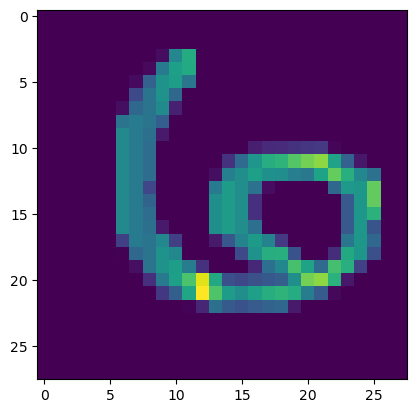

In [24]:
plt.imshow(x_test[54])

In [26]:
model.save("digit_recognizer_model.keras")


In [28]:
pip install opencv-python


  Obtaining dependency information for opencv-python from https://files.pythonhosted.org/packages/38/d2/3e8c13ffc37ca5ebc6f382b242b44acb43eb489042e1728407ac3904e72f/opencv_python-4.8.1.78-cp37-abi3-win_amd64.whl.metadata
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB 660.6 kB/s eta 0:00:58
   ---------------------------------------- 0.1/38.1 MB 544.7 kB/s eta 0:01:10
   ---------------------------------------- 0.1/38.1 MB 901.1 kB/s eta 0:00:43
   ---------------------------------------- 0.2/38.1 MB 1.2 MB/s eta 0:00:32
   ---------------------------------------- 0.3/38.1 MB 1.2 MB/s eta 0:00:33
    --------------------------------------- 0.5/38.1 MB 1.8 MB/s eta 0:00:22
    --------------------------------------- 0.7/38.1 MB 2.1 MB/s eta 0:00:18
   - -------------------------------------- 1.1/38.1 MB 2.7 MB/s eta 0:00:14
   - -------------------------------------- 1.8/38.1 MB 4.2 MB/s eta 0:00:09
   -- ----

In [29]:
import cv2


In [37]:
import cv2
import glob

# Get a list of image file paths in the 'testing_handwrite' directory with the '.png' extension
image_paths = glob.glob('testing_handwrite/*.png')

# Loop through the list of image paths and process each image
for image_path in image_paths:
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    resize = cv2.resize(gray, (28, 28), interpolation=cv2.INTER_AREA)
    new_img = tf.keras.utils.normalize(resize, axis=1)
    new_img = np.array(new_img).reshape(-1, img_size, img_size, 1)
    predictions = model.predict(new_img)
    # Process the predictions or do other tasks here


1/1 [==============================] - 0s 15ms/step


In [38]:
print(np.argmax(predictions))

1
